[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aipi590-ggn/aipi590-challenge-3/blob/main/notebooks/challenge3-pickandplace.ipynb)

# AIPI 590 — Challenge 3: RL in the Physical World

Train a robotic grasping policy in MuJoCo simulation (FetchPickAndPlace-v4) using SAC + Hindsight Experience Replay, then analyze the sim-to-real gap against a real 6-DOF arm platform.

## 0. Install

Run this cell first. If Colab prompts a runtime restart, restart and continue from the next cell — do not re-run this one.

In [ ]:
import subprocess
subprocess.run([
    'pip', 'install', '-q',
    'mujoco>=3.0.0',
    'gymnasium-robotics>=1.2.0',
    'stable-baselines3[extra]>=2.3.0',
    'moviepy>=1.0.3',
    'imageio[ffmpeg]',
], check=True)

CompletedProcess(args=['pip', 'install', '-q', 'mujoco>=3.0.0', 'gymnasium-robotics>=1.2.0', 'stable-baselines3[extra]>=2.3.0', 'moviepy>=1.0.3', 'imageio[ffmpeg]'], returncode=0)

## 1. Setup

In [ ]:
import sys, urllib.request
from pathlib import Path

# Download colab_utils from repo
utils_path = Path('/content/colab_utils.py')
if not utils_path.exists():
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/aipi590-ggn/aipi590-challenge-3/main/scripts/colab_utils.py',
        str(utils_path),
    )

sys.path.insert(0, '/content')
import colab_utils

REPO = colab_utils.prepare_notebook(pull_latest=True)
print(f'Repo ready at {REPO}')

Repo ready at /content/aipi590-challenge-3


In [ ]:
import gymnasium as gym
import gymnasium_robotics
import numpy as np
import matplotlib.pyplot as plt
import base64
from IPython.display import HTML, display

from stable_baselines3 import SAC
from stable_baselines3.her.her_replay_buffer import HerReplayBuffer
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

gym.register_envs(gymnasium_robotics)

RESULTS   = REPO / 'results'
MODELS_DIR = RESULTS / 'models'
VIDEOS_DIR = RESULTS / 'videos'
PLOTS_DIR  = RESULTS / 'plots'
for d in [MODELS_DIR, VIDEOS_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Imports OK')

Imports OK


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Simulation Environment

**FetchPickAndPlace-v4** tasks a 7-DOF Fetch robot arm with picking up a block from a table and placing it at a randomly sampled 3D goal position (which may be on the table or in the air). The reward is sparse: `0` on success (object within 5 cm of goal), `-1` otherwise.

This is strictly harder than reaching — the policy must learn to close the gripper at the right moment, lift the object, and transport it. HER is essential: without goal relabeling, the policy almost never sees a positive reward signal early in training.

In [ ]:
env = gym.make('FetchPickAndPlace-v4')
obs, _ = env.reset()

print('Observation keys:', list(obs.keys()))
print('  observation shape :', obs['observation'].shape)
print('  achieved_goal shape:', obs['achieved_goal'].shape)
print('  desired_goal shape :', obs['desired_goal'].shape)
print('Action space:', env.action_space)
env.close()

Observation keys: ['observation', 'achieved_goal', 'desired_goal']
  observation shape : (25,)
  achieved_goal shape: (3,)
  desired_goal shape : (3,)
Action space: Box(-1.0, 1.0, (4,), float32)


## 3. Training: SAC + HER

**Why SAC?** Off-policy, sample-efficient, handles continuous action spaces well. Entropy regularization prevents premature convergence — important here because the policy must explore a non-trivial grasp sequence before seeing any reward.

**Why HER?** FetchPickAndPlace has a sparse reward that is almost never triggered randomly. Hindsight Experience Replay relabels failed trajectories as successes toward the goal that was actually achieved (the object's final position), converting near-misses into learning signal. `goal_selection_strategy='future'` is empirically the strongest variant (Andrychowicz et al., 2017).

FetchPickAndPlace is harder than reaching — the policy must chain approach, grasp, lift, and transport. 1M timesteps is a reasonable budget for meaningful task performance. Expected runtime: ~25 min on A100, ~60 min on T4.

In [ ]:
LiveChartCallback = colab_utils.LiveChartCallback
publish_artifacts = colab_utils.publish_artifacts
publish_release = colab_utils.publish_release

In [ ]:
import multiprocessing, torch
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv

TOTAL_TIMESTEPS = 1_000_000  # ~25 min on A100, ~60 min on T4

N_ENVS = min(multiprocessing.cpu_count(), 8)
N_GPUS = torch.cuda.device_count()
BATCH_SIZE = 256 * max(1, N_GPUS)
GRADIENT_STEPS = N_ENVS

def make_env():
    def _init():
        return Monitor(gym.make('FetchPickAndPlace-v4'))
    return _init

try:
    train_env = SubprocVecEnv([make_env() for _ in range(N_ENVS)])
    vec_type = 'SubprocVecEnv'
except Exception:
    train_env = DummyVecEnv([make_env() for _ in range(N_ENVS)])
    vec_type = 'DummyVecEnv'

eval_env = Monitor(gym.make('FetchPickAndPlace-v4'))
print(f'{vec_type}: {N_ENVS} envs, {N_GPUS} GPU(s), batch={BATCH_SIZE}, grad_steps={GRADIENT_STEPS}')

model = SAC(
    'MultiInputPolicy',
    train_env,
    replay_buffer_class=HerReplayBuffer,
    replay_buffer_kwargs=dict(
        n_sampled_goal=4,
        goal_selection_strategy='future',
    ),
    verbose=0,
    buffer_size=int(1e6),
    learning_rate=1e-3,
    gamma=0.95,
    batch_size=BATCH_SIZE,
    gradient_steps=GRADIENT_STEPS,
    learning_starts=1000,  # <-- 加这一行，确保至少收集够几个完整 episode
    policy_kwargs=dict(net_arch=[256, 256, 256]),
    tensorboard_log=str(RESULTS / 'tb'),
)

callbacks = [
    LiveChartCallback(update_freq=2000),
    EvalCallback(
        eval_env,
        best_model_save_path=str(MODELS_DIR),
        log_path=str(RESULTS / 'eval_logs'),
        eval_freq=20_000,
        n_eval_episodes=20,
        verbose=0,
    ),
]

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callbacks)
model.save(str(MODELS_DIR / 'sac_her_fetchpickandplace_final'))
train_env.close()
eval_env.close()
print('Training complete.')


Training complete.


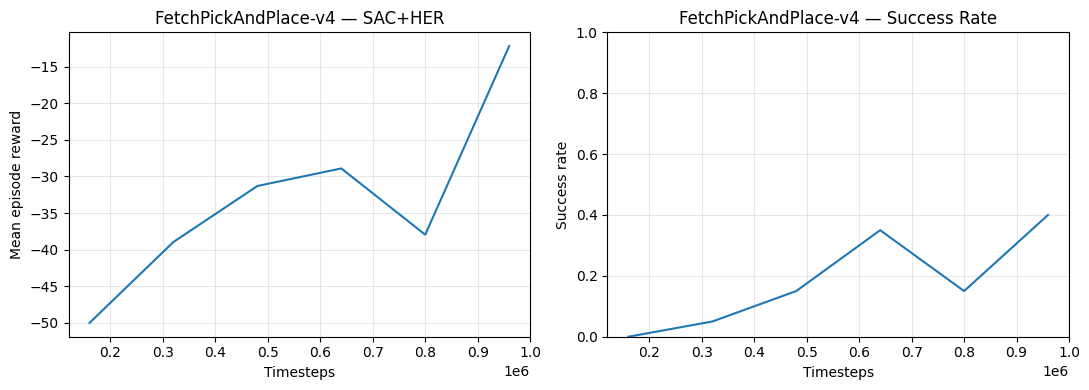

Saved to /content/aipi590-challenge-3/results/plots/training_curves.png


In [ ]:
eval_log = np.load(str(RESULTS / 'eval_logs' / 'evaluations.npz'))

timesteps    = eval_log['timesteps']
mean_reward  = eval_log['results'].mean(axis=1)
success_rate = (eval_log['results'] > -10).mean(axis=1)  # reached goal within ~10 steps

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(timesteps, mean_reward)
ax1.set_xlabel('Timesteps')
ax1.set_ylabel('Mean episode reward')
ax1.set_title('FetchPickAndPlace-v4 — SAC+HER')
ax1.grid(alpha=0.3)

ax2.plot(timesteps, success_rate)
ax2.set_xlabel('Timesteps')
ax2.set_ylabel('Success rate')
ax2.set_ylim(0, 1)
ax2.set_title('FetchPickAndPlace-v4 — Success Rate')
ax2.grid(alpha=0.3)

fig.tight_layout()
plot_path = PLOTS_DIR / 'training_curves.png'
fig.savefig(str(plot_path), dpi=150)
plt.show()
print(f'Saved to {plot_path}')

## 4. Evaluation

In [ ]:
import subprocess, os
subprocess.Popen(['Xvfb', ':1', '-screen', '0', '1024x768x24'])
os.environ['DISPLAY'] = ':1'

model = SAC.load(str(MODELS_DIR / 'best_model'), env=gym.make('FetchPickAndPlace-v4'))

record_env = gym.make('FetchPickAndPlace-v4', render_mode='rgb_array')
record_env = gym.wrappers.RecordVideo(
    record_env,
    str(VIDEOS_DIR),
    episode_trigger=lambda ep: True,
    name_prefix='fetchpickandplace',
)

n_episodes = 5
successes = 0
for ep in range(n_episodes):
    obs, _ = record_env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = record_env.step(action)
        done = terminated or truncated
    if info.get('is_success', False):
        successes += 1

record_env.close()
print(f'Success rate: {successes}/{n_episodes}')

videos = sorted(Path(VIDEOS_DIR).glob('*.mp4'))
if videos:
    b64 = base64.b64encode(videos[-1].read_bytes()).decode()
    display(HTML(f'<video controls width="480"><source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>'))
else:
    print('No video found — check VIDEOS_DIR.')

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/aipi590-challenge-3/results/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware 

Success rate: 5/5


## 5. Sim-to-Real Analysis

Training a grasping policy in MuJoCo and deploying it on a physical arm exposes a structured set of gaps. The analysis below is grounded in the **reBot-DevArm** platform (6-DOF, Robostride/Damiao actuators, ROS 2 Humble), which represents a realistic target for this task.

---

### 5.1 Contact and Gripper Modeling

This is the dominant failure mode for grasping — unlike reaching, the entire task depends on making and maintaining contact with an object.

MuJoCo models contact as convex-hull collisions with soft constraint forces. The Fetch gripper in simulation applies perfectly symmetric, instantaneous finger forces. Real grippers have:

- **Finger compliance.** Real rubber-tipped fingers deform on contact. The actual contact patch is larger and less predictable than the rigid model assumes. A policy that learned to close at a specific end-effector height will miss on hardware.
- **Micro-slip.** During transport, small vibrations cause the object to shift in the gripper. MuJoCo's contact model does not capture this — objects stay fixed once grasped in simulation.
- **Asymmetric grasp forces.** Real actuated fingers rarely apply identical force on both sides. The policy never experiences the resulting object rotation during grasp.

**Mitigation:** randomize object friction coefficients, add contact noise to gripper finger positions during training, and test grasp stability under perturbation before deployment.

---

### 5.2 Actuator Fidelity

FetchPickAndPlace-v4 uses idealized position/velocity control. The reBot-DevArm's Robostride/Damiao actuators introduce:

- **Gear backlash** in cycloidal/harmonic reducers — commands below the dead-band threshold produce no motion.
- **Control loop latency** (~10 ms at 100 Hz ROS 2 loop vs. sub-ms MuJoCo steps). During a fast approach trajectory, this lag shifts the actual grasp point by several millimeters.
- **Torque saturation** near joint limits, which can cause the arm to lurch rather than decelerate smoothly into the grasp pose.

**Mitigation:** randomize actuator delay (0–20 ms), add backlash noise to action execution, and enforce velocity limits matching real motor specs.

---

### 5.3 Observation Noise

The simulation policy receives noiseless ground-truth object position. On hardware:

- **Object localization** comes from a depth camera (e.g., RealSense D435): 2–5 mm spatial noise, plus pipeline latency of 30–100 ms depending on detection method. A policy that reaches for the object's last known position while the arm is moving will accumulate error.
- **Joint encoders** (Damiao magnetic encoders, ~0.1° resolution) introduce velocity estimation noise through numerical differentiation.

**Mitigation:** add observation noise wrappers during training; for object position specifically, simulate camera latency by using a stale observation from N steps prior.

---

### 5.4 Zero Calibration Drift

reBot-DevArm requires explicit zero-point calibration at each power cycle. At 650 mm reach, a 2° wrist error produces ~22 mm of end-effector position error. For grasping — where the gripper must close within ~2 cm of the object center — this is often enough to cause a miss entirely.

---

### 5.5 Domain Randomization Strategy

| Parameter | Range | Rationale |
|---|---|---|
| Object friction | 0.5–2× nominal | Surface variability |
| Gripper finger position noise | ±2 mm | Finger compliance |
| Action delay | 0–20 ms | ROS 2 control loop jitter |
| Joint obs noise | σ = 0.01 rad | Encoder resolution |
| Object position obs noise | σ = 3 mm | Depth camera uncertainty |
| Object obs latency | 1–5 steps | Camera pipeline delay |
| Link mass | ±10% | Manufacturing tolerance |

---

### 5.6 Beyond Domain Randomization

- **Residual policy learning:** Deploy the sim-trained policy on hardware, collect real grasp attempts, and train a small residual correction network to compensate for systematic biases (calibration offset, gripper asymmetry).
- **Real-to-sim adaptation:** Use real hardware trajectories to identify true contact parameters and actuator dynamics, update the simulation, and retrain. The reBot-DevArm's Isaac Sim integration (planned Q2 2026) is the intended path for this on the platform.

## 6. Publish Artifacts

In [ ]:
  import subprocess, os
  repo = '/content/aipi590-challenge-3'

  # Reset to remote main, keeping your files intact
  subprocess.run(["git", "fetch", "origin", "main"], cwd=repo, check=True)
  subprocess.run(["git", "reset", "--soft", "origin/main"], cwd=repo, check=True)

  # Re-commit just the data files on top of current remote
  subprocess.run(["git", "add", "docs/data/"], cwd=repo, check=True)
  subprocess.run(["git", "diff", "--cached", "--stat"], cwd=repo)  # verify what's staged
  subprocess.run(["git", "commit", "-m", "add trajectory data for FetchPickAndPlace visualization [skip ci]"], cwd=repo, check=True)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


CompletedProcess(args=['git', 'commit', '-m', 'add trajectory data for FetchPickAndPlace visualization [skip ci]'], returncode=0)

In [ ]:
subprocess.run(["git", "push", "origin", "main"], cwd=repo, check=True)

CalledProcessError: Command '['git', 'push', 'origin', 'main']' returned non-zero exit status 128.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
result = subprocess.run(["git", "push", "origin", "main"], cwd=repo, capture_output=True, text=True)
print("stdout:", result.stdout)
print("stderr:", result.stderr)

stdout: 
stderr: remote: Permission to aipi590-ggn/aipi590-challenge-3.git denied to SophiaYifei.
fatal: unable to access 'https://github.com/aipi590-ggn/aipi590-challenge-3.git/': The requested URL returned error: 403



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# 看看模型文件在哪
import os
for f in os.listdir(MODELS_DIR):
    print(f, os.path.getsize(MODELS_DIR / f) / 1e6, 'MB')

best_model.zip 6.290758 MB
sac_her_fetchpickandplace_final.zip 6.290742 MB


In [ ]:
from google.colab import files
files.download(str(MODELS_DIR / 'best_model.zip'))
files.download(str(MODELS_DIR / 'sac_her_fetchpickandplace_final.zip'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 打包所有结果
import shutil
shutil.make_archive('/content/challenge3_results', 'zip', str(RESULTS))
files.download('/content/challenge3_results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Publish artifacts and models to GitHub
publish_artifacts('add training curves, rollout video, and notebook')
# publish_release('v1-challenge3-1m', description='SAC+HER policy (1M steps, FetchPickAndPlace-v4)')


Authenticated. Publishing…
No artifact changes to commit.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 7. Extract Trajectories for Interactive Visualization

In [ ]:
from scripts.trajectory_extractor import extract_trajectory, save_trajectories, generate_versioned_filename

episodes = extract_trajectory(model, env_id='FetchPickAndPlace-v4', n_episodes=5, deterministic=True)
filename = generate_versioned_filename('FetchPickAndPlace-v4', len(episodes))
save_trajectories(episodes, REPO / 'docs' / 'data' / filename)

print('Trajectories saved. View them at:')
print('https://aipi590-ggn.github.io/aipi590-challenge-3/')

publish_artifacts('add trajectory data for interactive visualization')


Saved 5 trajectories to /content/aipi590-challenge-3/docs/data/trajectories-fetchpickandplace-5ep.json
Trajectories saved. View them at:
https://aipi590-ggn.github.io/aipi590-challenge-3/


Authenticated. Publishing…
No artifact changes to commit.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
